Data loading complete. Total valid data points after filtering 0-values: 55


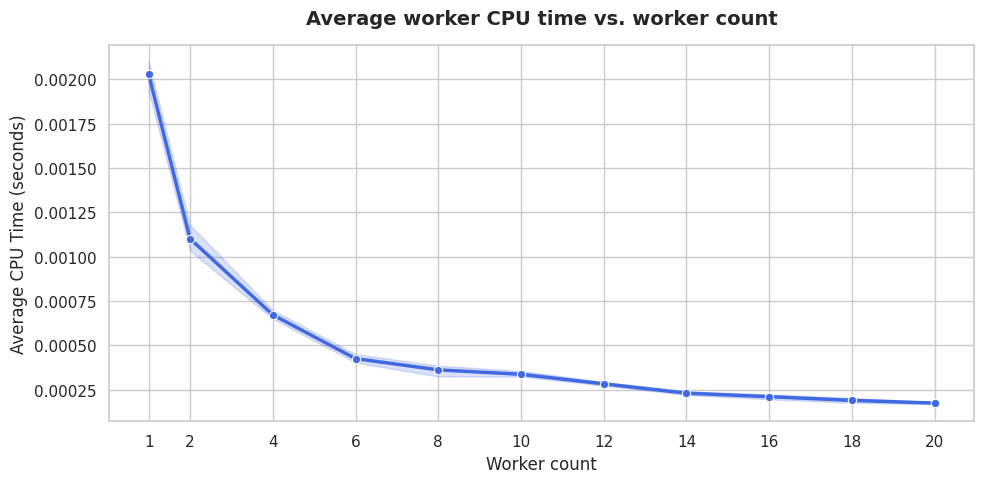

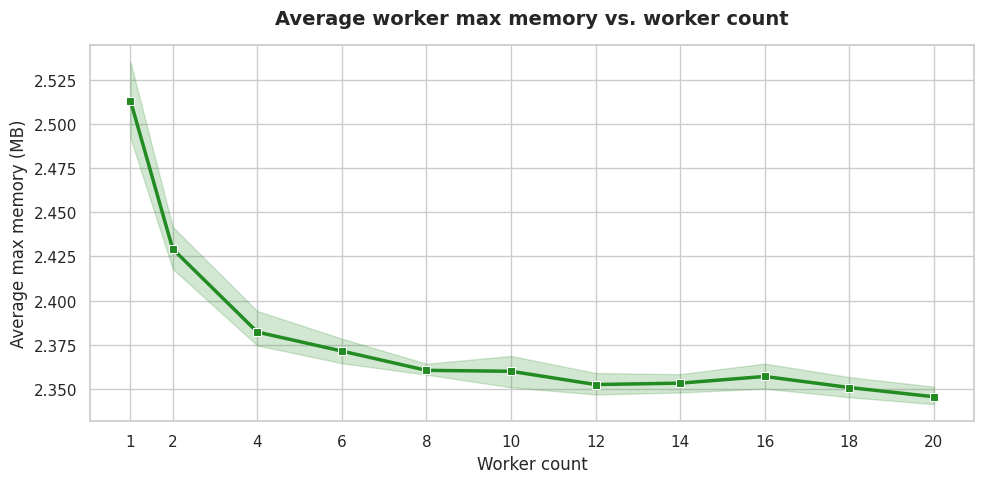

In [1]:
# %% [markdown]
# # Worker Performance Scaling Analysis (with 0-Value Filtering)
# This notebook loads the `benchmark_results.json` file, filters out invalid or zero values, 
# and visualizes how the average worker CPU time and maximum memory footprint scale with the number of workers.

# %%
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up global plotting aesthetics
sns.set_theme(style="whitegrid")

# %% [markdown]
# ## 1. Load, Parse, and Filter Benchmark Data
# We extract the metrics inside `worker_analysis` dynamically and explicitly filter out any values equal to `0`.

# %%
# Load the JSON benchmark data
with open("benchmark_results.json", "r") as f:
    raw_data = json.load(f)

# Process and flatten the nested worker metrics
rows = []
for entry in raw_data["data"]:
    workers_size = entry["workers_size"]
    cluster_size = entry["cluster_size"]
    run = entry["run"]
    timings = entry["timings"]
    worker_analysis = timings.get("worker_analysis", {})
    
    # Extract worker metrics dynamically, FILTERING OUT values equal to 0
    cpu_times = [v for k, v in worker_analysis.items() if "cpu_time" in k and v != 0]
    mem_mbs = [v for k, v in worker_analysis.items() if "max_memory_mb" in k and v != 0]
    
    # Calculate averages for the current run only if we have valid non-zero data points
    avg_cpu = np.mean(cpu_times) if cpu_times else None
    avg_mem = np.mean(mem_mbs) if mem_mbs else None
    
    rows.append({
        "cluster_size": cluster_size,
        "workers_size": workers_size,
        "run": run,
        "avg_worker_cpu_time_s": avg_cpu,
        "avg_worker_max_memory_mb": avg_mem
    })

# Convert to structured DataFrame
df = pd.DataFrame(rows)

# Drop any rows where the computed metrics are completely missing (NaN)
df = df.dropna(subset=["avg_worker_cpu_time_s", "avg_worker_max_memory_mb"])

# Additional safety filter: Ensure no final averaged row values are equal to 0
df = df[(df["avg_worker_cpu_time_s"] != 0) & (df["avg_worker_max_memory_mb"] != 0)]

print(f"Data loading complete. Total valid data points after filtering 0-values: {len(df)}")
df.head()

# %% [markdown]
# ## 2. Plot Average Worker CPU Time vs. Worker Count

# %%
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df, 
    x="workers_size", 
    y="avg_worker_cpu_time_s", 
    marker="o", 
    color="royalblue", 
    linewidth=2.5
)

plt.title("Average worker CPU time vs. worker count", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Worker count", fontsize=12)
plt.ylabel("Average CPU Time (seconds)", fontsize=12)
plt.xticks(sorted(df["workers_size"].unique()))
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 3. Plot Average Worker Max Memory vs. Worker Count

# %%
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df, 
    x="workers_size", 
    y="avg_worker_max_memory_mb", 
    marker="s", 
    color="forestgreen", 
    linewidth=2.5
)

plt.title("Average worker max memory vs. worker count", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Worker count", fontsize=12)
plt.ylabel("Average max memory (MB)", fontsize=12)
plt.xticks(sorted(df["workers_size"].unique()))
plt.tight_layout()
plt.show()

/tmp/ipykernel_41435/2064930613.py:8: UserWarning: The markers list has more values (6) than needed (1), which may not be intended.
  sns.lineplot(


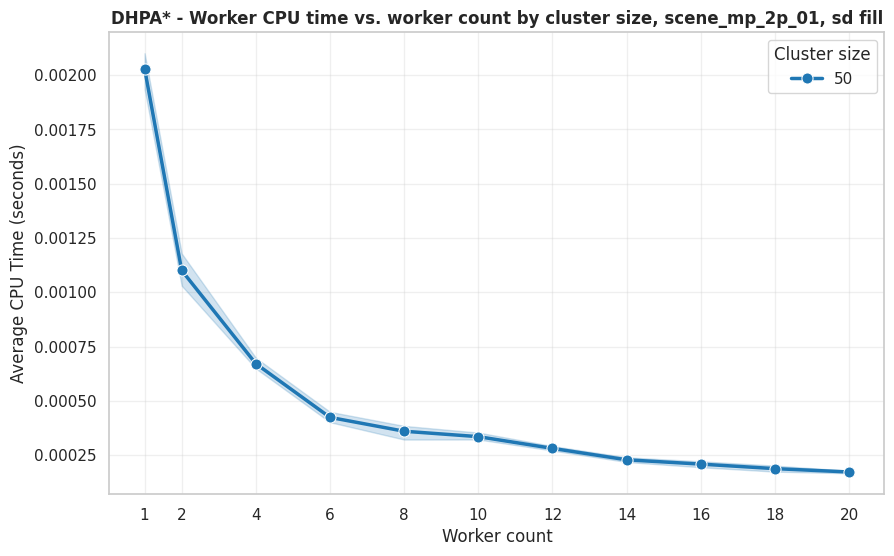

/tmp/ipykernel_41435/2064930613.py:31: UserWarning: The markers list has more values (6) than needed (1), which may not be intended.
  sns.lineplot(


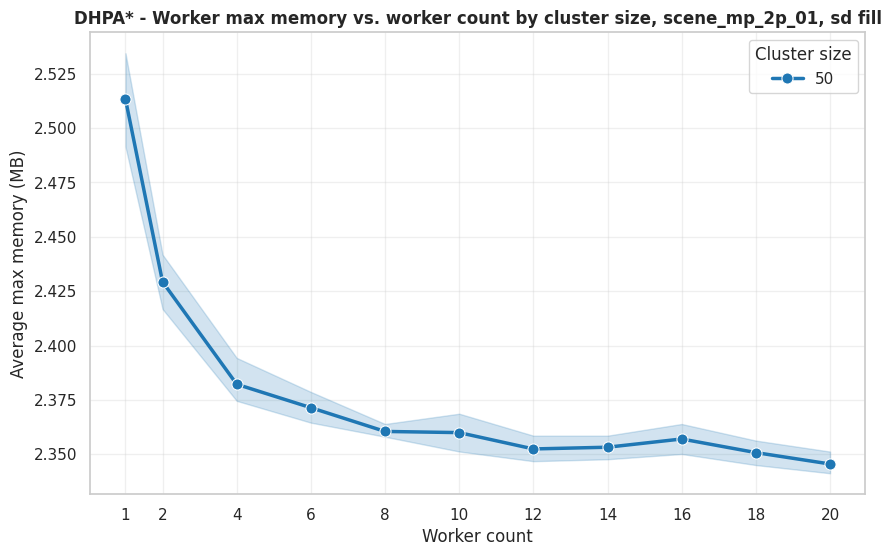

In [2]:
# %% [markdown]
# ## 4. Scaling Metrics by Cluster Size
# This section visualizes how both worker CPU time and memory footprint scale with the worker count, broken down with a unique line for each `cluster_size`.

# %%
# 4a. Worker CPU Time vs. Worker Count by Cluster Size
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df, 
    x="workers_size", 
    y="avg_worker_cpu_time_s", 
    hue="cluster_size",
    style="cluster_size",                  # 1. Added style to map markers to each cluster size
    markers=['o', 'D', 'v', 's', '^', '*'], # 2. Replaced 'x' with 'D' to prevent mixing filled & line art
    markersize=8,                          # Optional: increases marker visibility
    palette="tab10", 
    linewidth=2.5
)

plt.title("DHPA* - Worker CPU time vs. worker count by cluster size, scene_mp_2p_01, sd fill", fontsize=12, fontweight='bold')
plt.xlabel("Worker count", fontsize=12)
plt.ylabel("Average CPU Time (seconds)")
plt.xticks(sorted(df["workers_size"].unique()))
plt.legend(title="Cluster size")
plt.grid(True, alpha=0.3)
plt.show()

# %%
# 4b. Worker Max Memory vs. Worker Count by Cluster Size
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df, 
    x="workers_size", 
    y="avg_worker_max_memory_mb", 
    hue="cluster_size",
    style="cluster_size",                  # 1. Added style to map markers to each cluster size
    markers=['o', 'D', 'v', 's', '^', '*'], # 2. Replaced 'x' with 'D' to prevent mixing filled & line art
    markersize=8,                          # Optional: increases marker visibility
    palette="tab10", 
    linewidth=2.5
)

plt.title("DHPA* - Worker max memory vs. worker count by cluster size, scene_mp_2p_01, sd fill", fontsize=12, fontweight='bold')
plt.xlabel("Worker count", fontsize=12)
plt.ylabel("Average max memory (MB)", fontsize=12)
plt.xticks(sorted(df["workers_size"].unique()))
plt.legend(title="Cluster size")
plt.grid(True, alpha=0.3)
plt.show()

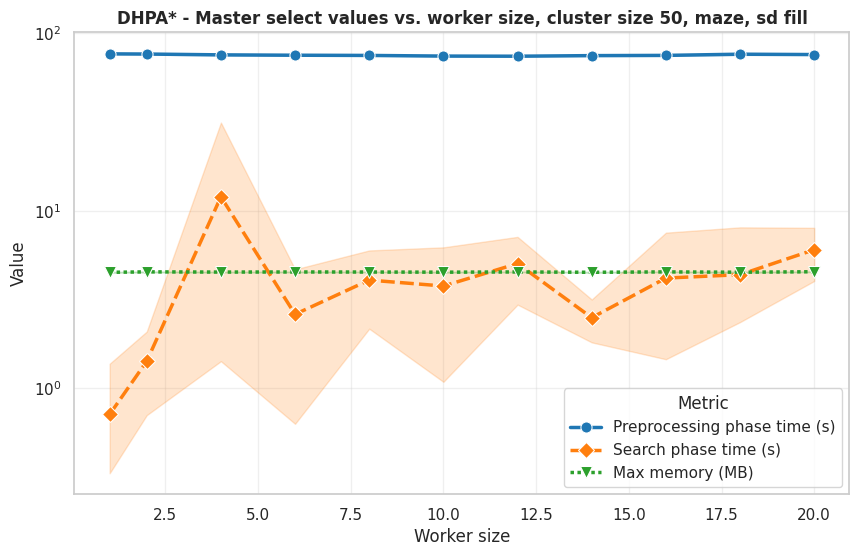

In [4]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Load the benchmark results
with open('benchmark_results.json', 'r') as f:
    res = json.load(f)

# 2. Parse raw run entries into a clean DataFrame, filtering for cluster sizes 100 and 150
records = []
for entry in res['data']:
    c_size = entry['cluster_size']
    w_size = entry['workers_size']
    timings = entry['timings']
    
    if c_size in res['metadata']['cluster_sizes']:
        records.append({
            'cluster_size': c_size,
            'workers_size': w_size,
            'preprocess_time_s': (
                timings.get('preprocessed', 0) +
                timings.get('inter_edges', 0)
            ),
            'master_search_time_s': (
                timings.get('finish_abstract_graph', 0) +
                timings.get('found_graph_path', 0) +
                timings.get('found_overall_path', 0)
            ),
            'max_memory_mb': timings.get('max_memory', 0)
        })

df = pd.DataFrame(records)

# 3. Melt the DataFrame to long-form for seaborn hue/style mapping
df_melted = df.melt(
    id_vars=['workers_size'],
    value_vars=['preprocess_time_s', 'master_search_time_s', 'max_memory_mb'],
    var_name='Metric',
    value_name='Value'
)

# Rename metrics for professional display
metric_labels = {
    'preprocess_time_s': 'Preprocessing phase time (s)',
    'master_search_time_s': 'Search phase time (s)',
    'max_memory_mb': 'Max memory (MB)'
}
df_melted['Metric'] = df_melted['Metric'].map(metric_labels)

# 4. Generate the single combined plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=df_melted,
    x="workers_size",
    y="Value",
    hue="Metric",
    style="Metric",
    markers=['o', 'D', 'v'],
    markersize=8,
    palette="tab10",
    linewidth=2.5,
    errorbar='ci',  # Computes SD across cluster sizes [100, 150] & runs combined
    ax=ax
)

# Apply logarithmic scale to Y-axis
ax.set_yscale('log')

# Title, Labels, and Formatting
ax.set_title('DHPA* - Master select values vs. worker size, cluster size 50, maze, sd fill', fontsize=12, fontweight='bold')
ax.set_xlabel('Worker size', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.grid(True, alpha=0.3)

plt.show()